# **Comparative Analysis of Literary Translations in the Odyssey: Type-Token Ratio in Depth**

This is a comparative Type-Token Ratio (TTR) analysis of six translations spanning roughly the last century: 1919–2018. 

## **Road Map**

### I. Libraries, files, and paths

### II. The Texts

1. Bibliographic information about the translators  
    a) Name, date, publisher, digital source  
    c) Etymologic bias, character names and place names  

2. The translators at a glance tokenwise  
    a) Lenght and distribution  
        - Total token-words ratio  
        - Book distribution  
        - Choosing a baseline: Murray(?)  
    b) Token quality check  
        - DataFrame of firstlines (books, authors)  
        - Visial auditing Book 6  
        - Purity index   
            * by book  
            * aggregated  

### III. TTR Analysis

1. All-in, straightforward model  
    a) TTR Computation  
    b) Shapiro-Wilk test to check for normality  
    c) One-wat ANOVA for overall differences  
    d) Pairwise t-test using Bonferroni coprrection  
    c) Meassuring effect size ussing Cohen's d  

2. Adaptive models  
    a) Mixed-Effects model: author fixed effect / book as random effect  
    b) Standardized TTR:   
    c) Moving-average TTR: translation as temporal change  

3. Supplement models  
    a) Lexical Density   
    b) Diachronic analysis  
    c) Semantic fields:  

### IV. Discussing Results
    

## **I. Libraries, files, and paths**

In [1]:
#### Other libraries
import sys
import os

import ast
from collections import Counter

import re
import nltk

#### Pandas set-up
import numpy as np
import pandas as pd

import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

import scipy.stats as stats
from itertools import combinations

In [2]:
# ----------------------------------------------------------------------
# Visualization
# ----------------------------------------------------------------------

sys.path.append('/Users/debr/English-Homer/functions') 
import matplotlib.pyplot as plt
import seaborn as sns

import e_chroma as chroma # My Vizualization library
import e_plots as oz      # My custom plots library
import e_nlp_ody as e     # Import my functions

import warnings           # Nononsense provision
warnings.filterwarnings('ignore')


* Got some chroma in your soma, Oma!
	 »----> use chroma.save_figure(fig, 'my_plot')
Default output path: ./Homer_xplots/

* OZ is behind the curtain!
	 »----> use oz.<func>
	 »----> also, oz goes chroma (for styling)!

* The editor is in the house!
	 »----> use e.<func> e.g. nlp = e.NLPPipeline(language='english')

Stopwords customized:
  Added: {"'and", 'ten', 'n', 'three', 'seven', 'six', 'five', 'four', 'nine', 'two', 'eight', "'", 'one'}
  Removed: {''}
  Total stopwords: 211
Punctuation customized:
  Keeping: {'', '-'}
  Additional removals: {'\\', ',\n        "\'",\n        ', '—', '…', '-', "'"}
  Punctuation to be removed: !"#$%&'()*+,,
        "'",
        -./:;<=>?@[\]^_`{|}~—…


[nltk_data] Downloading package punkt_tab to /Users/debr/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
# ----------------------------------------------------------------------
# File management
# ----------------------------------------------------------------------

# TO UPDATE
nb_id = "TTR_Six_Mo-03_31_25"
output_path = f"./{nb_id}/"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
output_path_plots = f"./{output_path}/{nb_id}_plots/"
os.makedirs(os.path.dirname(output_path_plots), exist_ok=True)
#chroma.set_output_path(output_path_plots)

In [4]:
# ----------------------------------------------------------------------
# Odysseys
# ----------------------------------------------------------------------

odysseys = ['AT_Murray', 'Fitzgerald', 'Lattimore', 'Fagles', 'Wilson', 'Green']

dfs = []

for odyssey in odysseys:
    filepath = f"/Users/debr/odysseys_en/dataframed/Odyssey_{odyssey}_DataFrame.csv"
    temp_df = pd.read_csv(filepath)  
    dfs.append(temp_df)  # Append it to the list

df = pd.concat(dfs, axis=0, ignore_index=True)

df["text"] = df["text"].apply(ast.literal_eval)
df = df[['author', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens']]
df["diff"] = df["num_words"] - df["num_tokens"]
e.check_df(df)

Mr righteous here has no missing values!

* df columns: Index(['author', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens',
       'diff'],
      dtype='object') 

* Shape: (144, 7) 

* Total memory in MB: 4.30924


In [5]:
df.sample(4, random_state=4)

,author,book_num,text,tokens,num_words,num_tokens,diff
128,Green,9,"[Then resourceful Odysseus responded to him, s...","['resourceful', 'odysseus', 'responded', 'sayi...",5950,2786,3164
5,AT_Murray,6,"[So here Odysseus slept, overcome by sleep and...","['odysseus', 'slept', 'overcome', 'sleep', 'to...",3470,1492,1978
61,Lattimore,14,[But Odysseus himself left the harbor and asce...,"['odysseus', 'left', 'harbor', 'ascended', 'ru...",6328,2728,3600
29,Fitzgerald,6,"[Far gone in weariness, in oblivion, \n, the n...","['far', 'gone', 'weariness', 'oblivion', 'nobl...",2907,1454,1453


## **II. The Texts**
### **1. Bibliographic information about the translators**

Here is a brief description of each translation, starting with bibliographic data: a) Name, date, publisher, source, etc.; followed by labelling their b) Etymologic bias, regarding characters and places names.

| Author                  | Year | Period       | Span  | Verse | Publisher               | Edition | Source                | URL                                                                 | Notes | Bibliography |
|-------------------------|------|-------------|-------|-------|-------------------------|---------|------------------------|---------------------------------------------------------------------|-------|--------------|
| Augustus Taber Murray  | 1919 | Modernism   | 1910-1940 | FALSE | Harvard UP, Loeb          | 1919    | Scaife Viewer, Tufts University | [Link](https://scaife.perseus.org/library/urn:cts:greekLit:tlg0012.tlg002/) | "No more faithful translation of Homer was ever made, and its elegance matched its fidelity. Homer's formulaic epithets, phrases, and sentences were consistently rendered, and his artificial amalgam of dialects and archaic vocabulary were, as was perfectly acceptable in those days, reflected in archaic English." From the Preface to the revised 1995 edition, also in the Loeb collection.  |*Homer. The Odyssey, Vol. 1-2. Murray, A. T. (Augustus Taber), translator. London: William Heinmann; New York: G.P. Putnam's Sons, 1919.* |
| Robert Fitzgerald      | 1961 | (Ur)Postmodernism   | 1960-1979 | TRUE  | Doubleday & Company, Inc.  | Second 1963 Edition    | Internet Archive       | [Link](https://archive.org/details/homer-the-odyssey-800-bce-robert-fitzgerald-tr-1961) | "Written in very readable, American “plain style” language" (Carolyn Clark, Best American Poetry, 2020) | *Homer. The Odyssey. Fitzgerald, Robert, translator. New York: Doubleday & Company, Inc., 1961* | 
| Richmond Lattimore     | 1965 | (Ur)Postmodernism   | 1960-1979 | TRUE      |     Farrar, Straus & Giroux                    | First 1965 Edition          | Harper Collins E-Books               | NONE | "Prose-like verse translation" (Carolyn Clark, Best American Poetry, 2020). | *Homer. The Odyssey. Lattimore, Richmond, translator. New York: Doubleday & Company, Inc., 1965* | 
| Robert Fagles         | 1996 | Postmodernism | 1980-1999 | TRUE      |  Penguin                       | First 1996 Edition        | PDF SCAN               | NONE | | *Homer. The Odyssey. Fagles, Robert, translator. University of California Press, 1996*|
| Emily Wilson          | 2017 | Contemporary | >2000 | TRUE      | W.W. Norton & Company Inc.         | First 2017 Edition | PDF SCAN  | NONE| | *Homer. The Odyssey. Wilson, Emily, translator. W.W. Norton & Company Inc., 2017* |
| Peter Green           | 2018 | Contemporary | >2000 | TRUE | University of California Press | Digital | EBSCOhost | [Link](https://search.ebscohost.com/login.aspx?direct=true&scope=site&db=nlebk&db=nlabk&AN=1696363) | | *Homer. The Odyssey. Green, Peter, translator. University of California Press, 2018* |

Use of Latin vs Greek form for characters' name by translator. There is an inconsistency in their us. Up until Fagles, every translator used a mix of direct Greek transliteratio and the conventional name passed on by the earlier tradition. 

- **Murray:** Lean to use Greek (Telemakhos, Menelaos) yet more popular names (Odysseus, Athena) reamin in their Latin form
- **Fitzgerald:** Opts for transliterating Greek phonetics, like Murray Telemakhos but to an extreme in Akhilleus, however others retain their popular form.
- **Lattimore:** Less Greek than Fitzgerald (Telemachus) but still Athene and Achilleus
- **Fagles:** Experiment less with character names and sttles on the convention
- **Wilson:** Follows the same names as Fagles
- **Green:** Returns to a Greek flavor by including Greek diacritics to the names: Achillēs, Menelaös, Tēlemachos, Athēnē

The names of places follows the same patter. This will be analyzed thoroughly in the Name Entity Recognition step of the project.

#### 2. **The translators at a glance tokenwise**
**a) Lenght and distribution**  
- Total token-words ratio  
- Book distribution  
- Choosing a baseline: Murray(?)  

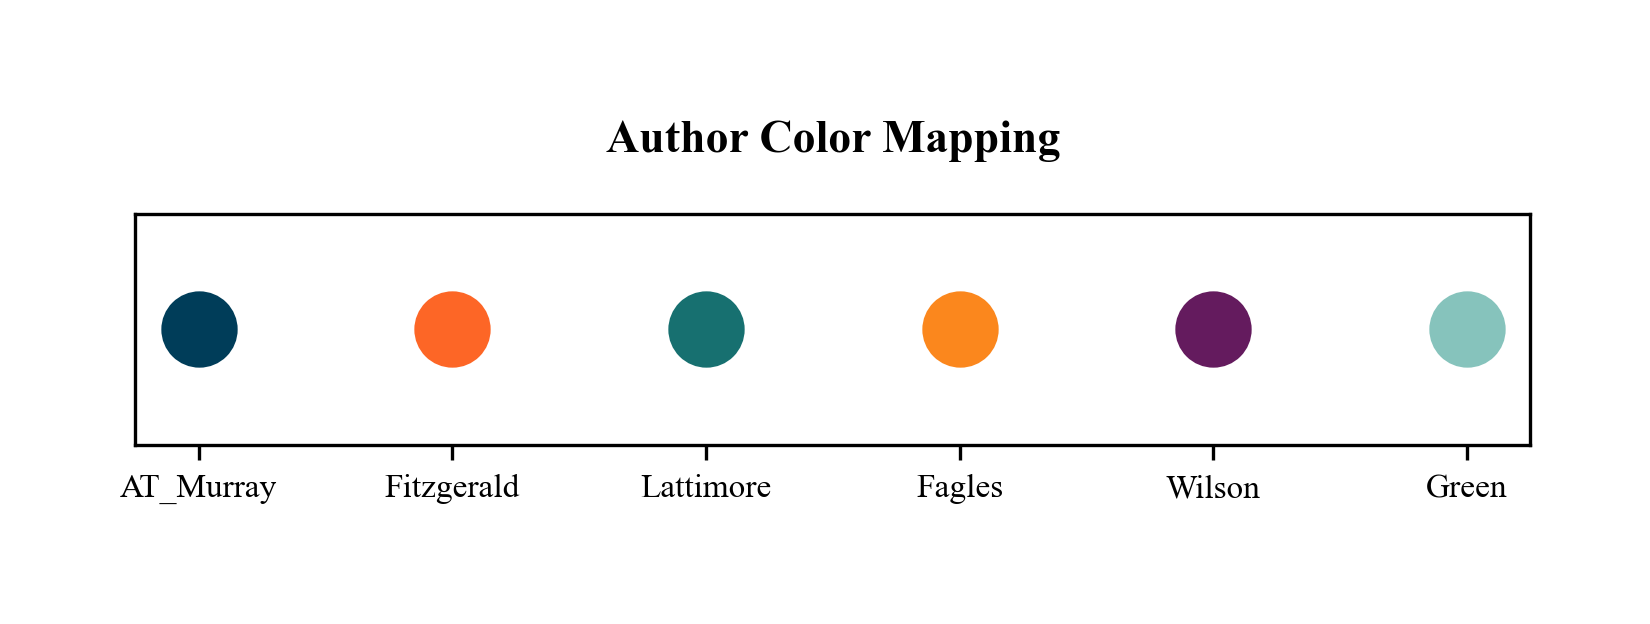

In [6]:
# ----------------------------------------------------------------------
# Create a color mapping for authors
# ----------------------------------------------------------------------

authors = df["author"].unique()
palette = {author: color for author, 
           color in zip(authors, chroma.color_palette.values())}

plt.figure(figsize=(6, 1))

for i, (author, color) in enumerate(palette.items()):
    plt.scatter(i, 0, color=color, s=300)

plt.xticks(range(len(palette)), palette.keys(), fontsize=8)
plt.yticks([])
plt.title("Author Color Mapping", fontsize=11)
plt.savefig(f"{output_path_plots}author_color_mapping-{nb_id}.png")
plt.show()

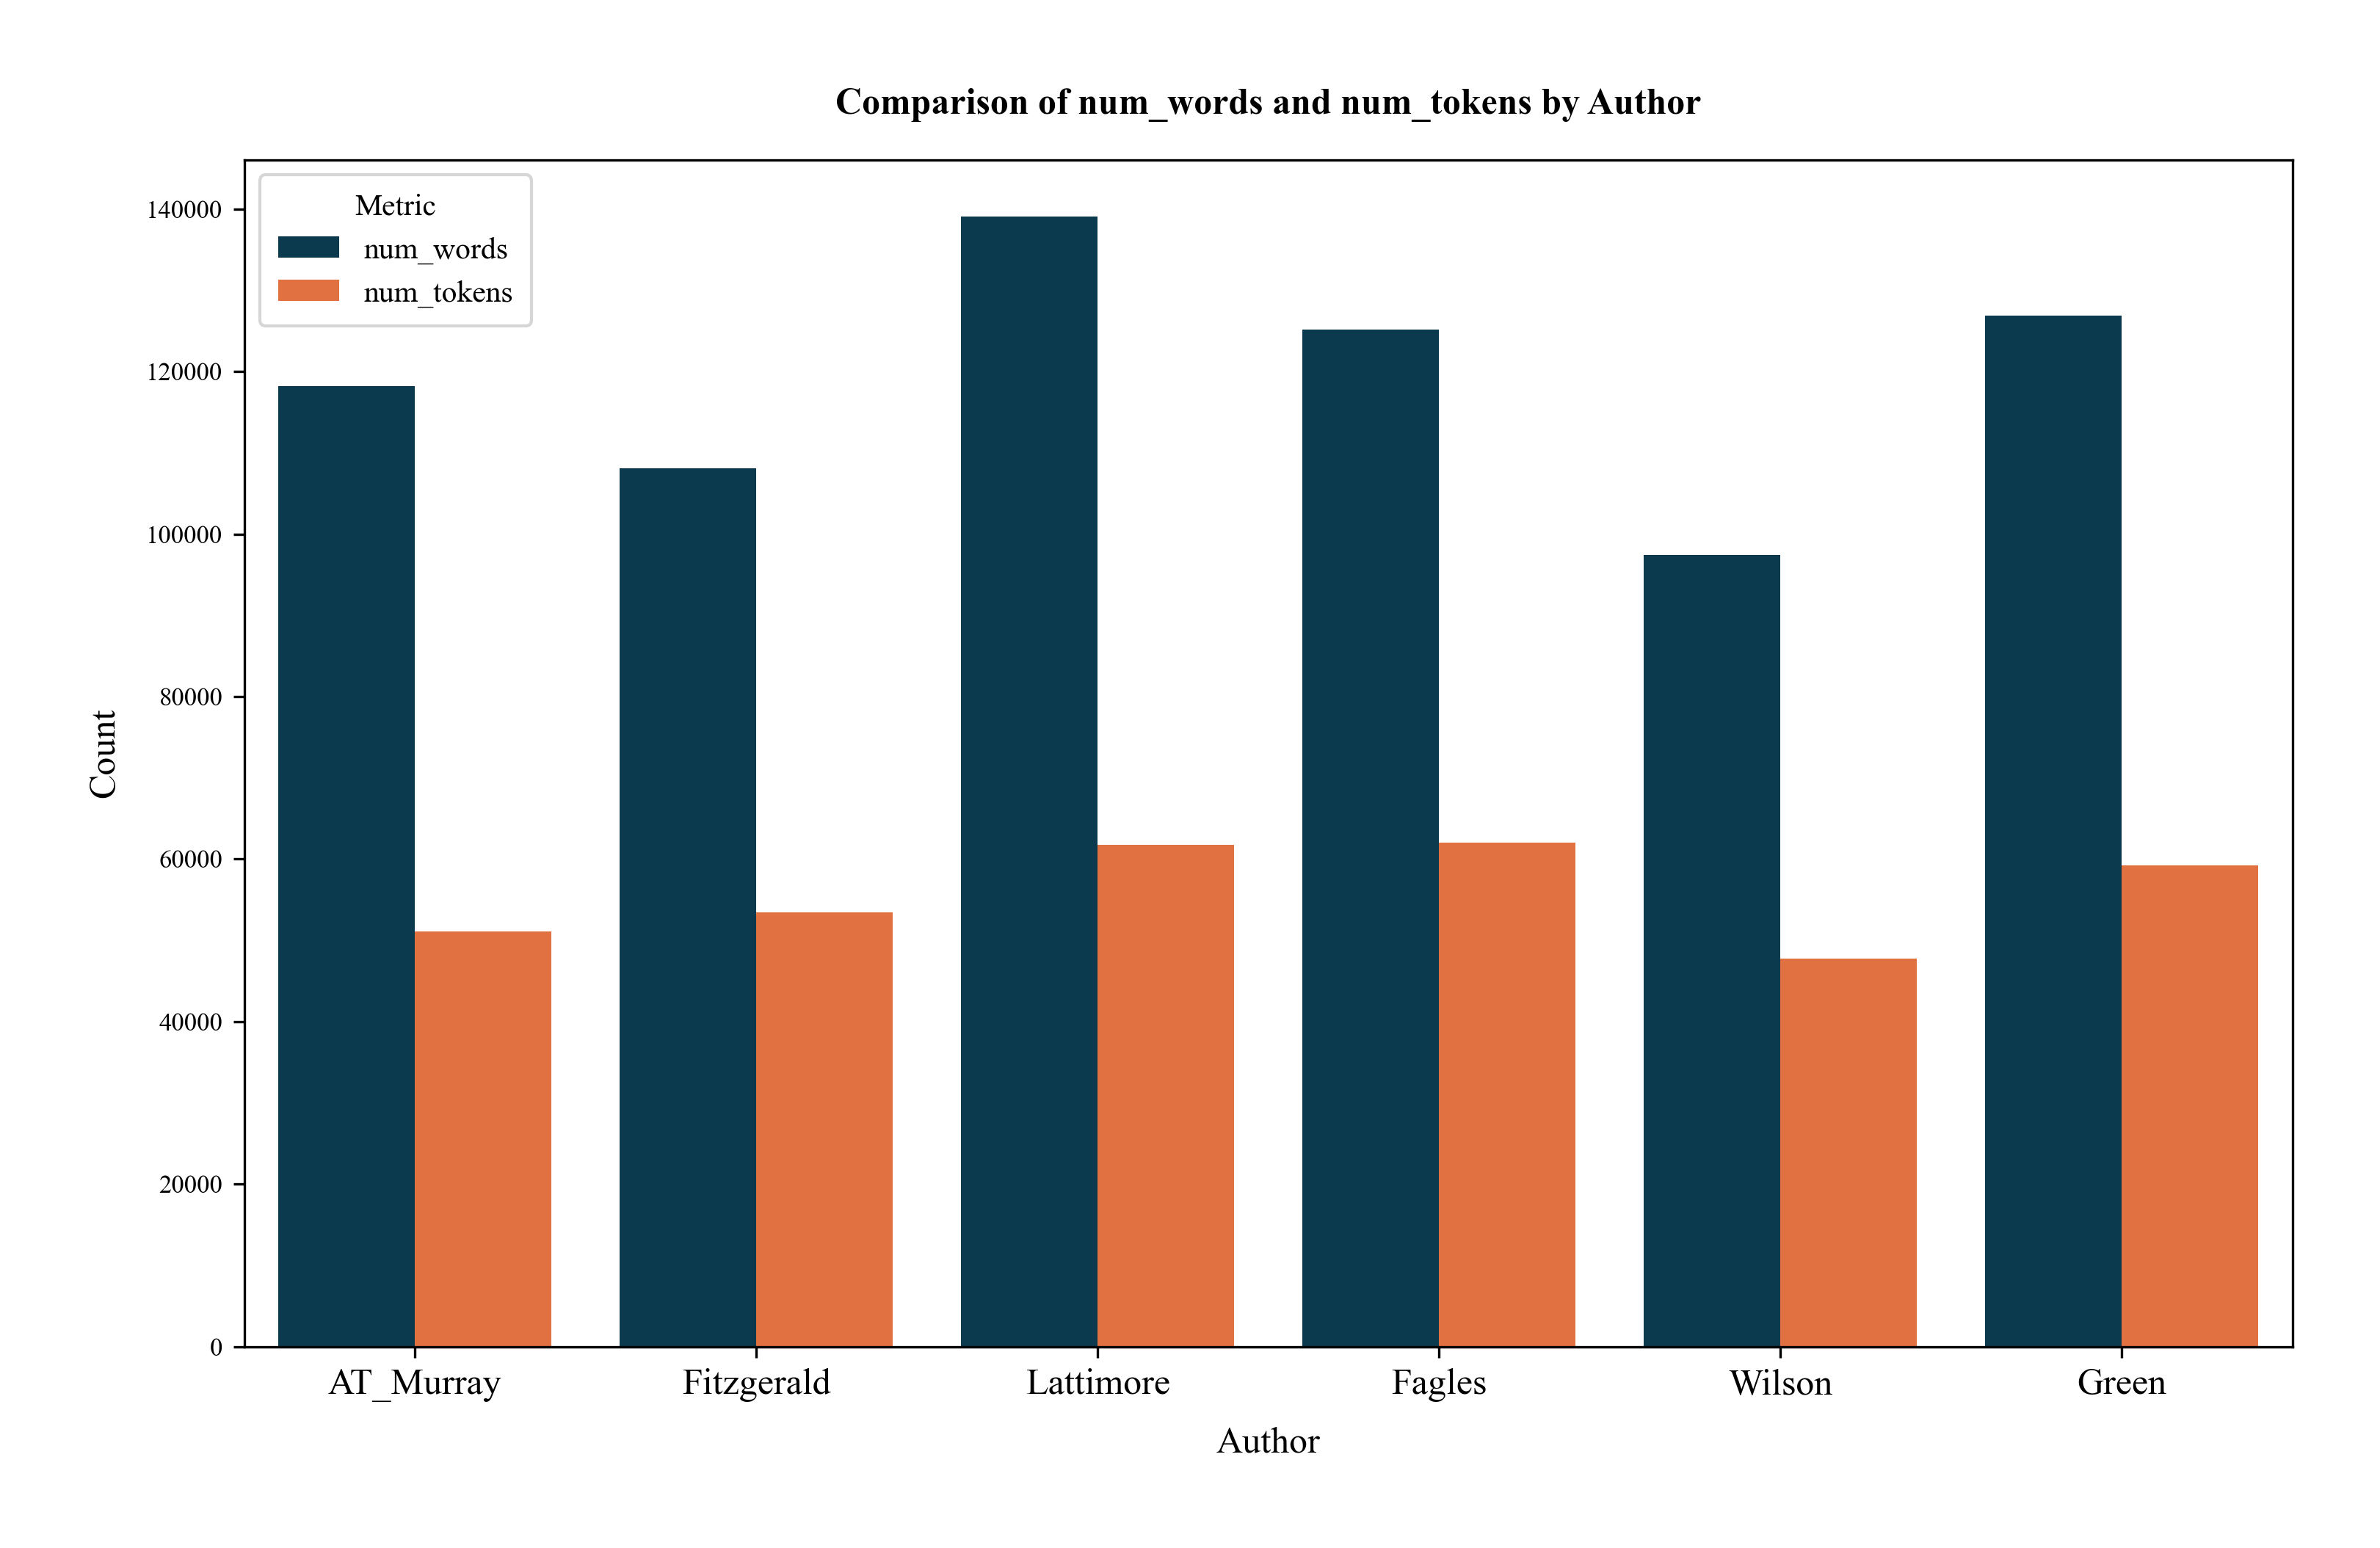

In [7]:
# ----------------------------------------------------------------------
# Side by side comparison of num_words and num_tokens by translator
# ----------------------------------------------------------------------

# Reshape the DataFrame to a long format
df_melted = df.melt(id_vars=["author"], value_vars=["num_words", "num_tokens"],
                     var_name="Metric", value_name="Count")

# Create the bar plot
sns.barplot(data=df_melted, x="author", y="Count", hue="Metric", 
            estimator=sum, errorbar=None)

plt.xticks()
plt.xlabel("Author")
plt.ylabel("Count")
plt.title("Comparison of num_words and num_tokens by Author")
plt.legend(title="Metric")
plt.savefig(output_path_plots + f"words_tokens-{nb_id}.png")
plt.show()

In [8]:
# Token word ratio by author
df["token_word_ratio"] = df["num_tokens"] / df["num_words"]
print(df.groupby("author")["token_word_ratio"].mean())

author
AT_Murray     0.431746
Fagles        0.495281
Fitzgerald    0.494190
Green         0.466653
Lattimore     0.443799
Wilson        0.489414
Name: token_word_ratio, dtype: float64


In [9]:
baseline_author = "AT_Murray"
baseline_ratio = df[df["author"] == baseline_author]["token_word_ratio"].mean()

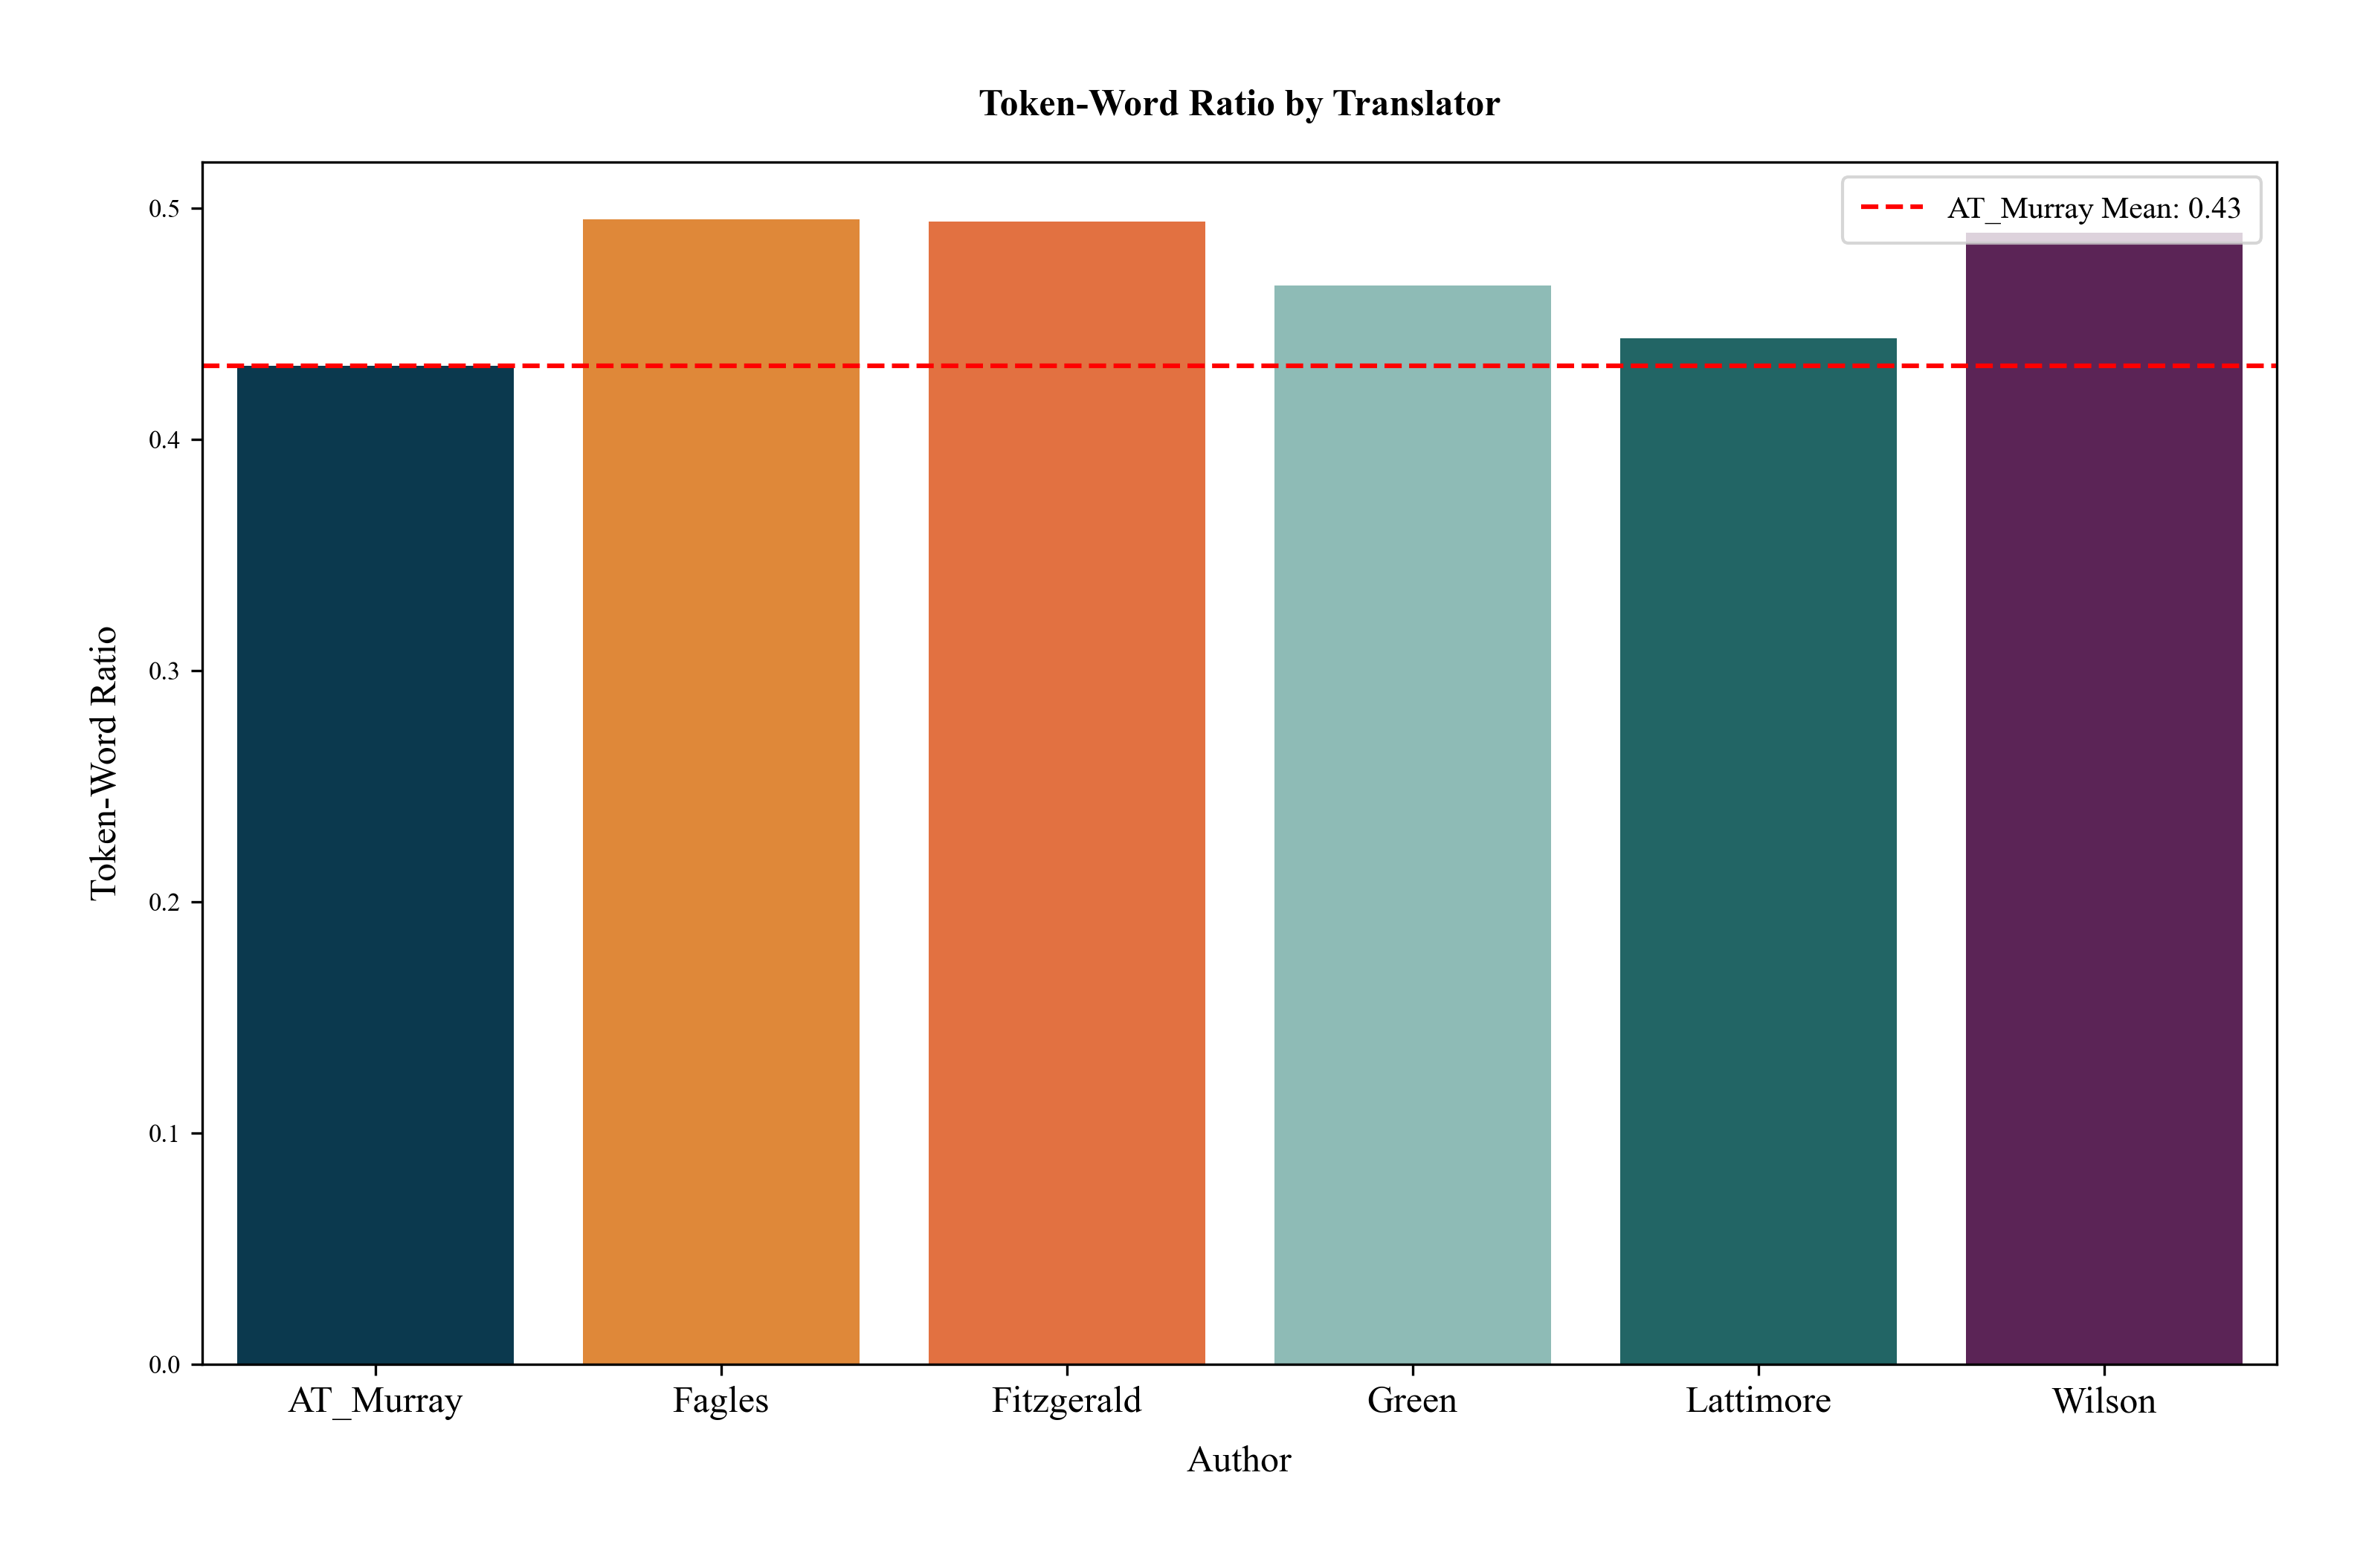

In [10]:
# ----------------------------------------------------------------------
# Compute mean token-word ratio per author
# ----------------------------------------------------------------------

author_means = df.groupby("author")["token_word_ratio"].mean().reset_index()

sns.barplot(data=author_means, x="author", y="token_word_ratio",
             palette=palette)

# Baseline (horizontal line for reference author)
plt.axhline(baseline_ratio, color="red", linestyle="--", 
            label=f"{baseline_author} Mean: {baseline_ratio:.2f}")

plt.xlabel("Author")
plt.ylabel("Token-Word Ratio")
plt.title("Token-Word Ratio by Translator")
plt.xticks() 
plt.legend()
plt.savefig(output_path_plots + f"token_word_ratio-{nb_id}.png")  
plt.show()

####    b) Token quality check

- DataFrame of firstlines (books, authors)
- Visial auditing of the Proems by author
- Purity index 
    * by book
    * aggregated

In [11]:
# ----------------------------------------------------------------------
# First line of each book by author
# ----------------------------------------------------------------------

df["first_line"] = df["text"].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else "")
first_line_df = df.groupby("author").first().reset_index()[["author", "first_line"]]
first_line_df

,author,first_line
0,AT_Murray,"Tell me, O Muse, of that many-sided hero who\n"
1,Fagles,"Sing to me of the man, Muse, the man of twists..."
2,Fitzgerald,"Sing in me, Muse, and through me tell the stor..."
3,Green,"The man, Muse—tell me about that resourceful m..."
4,Lattimore,"Tell me, Muse, of the man of many ways, who wa..."
5,Wilson,Tell me about a complicated man.\n


In [12]:
# ----------------------------------------------------------------------
# First sentence extraction
# ----------------------------------------------------------------------

# Step 1: Convert the 'text' column from a list to a string and remove \n characters
df['text_string'] = df['text'].apply(lambda x: "".join(x).replace("\n", "") if isinstance(x, list) else "")

# Step 2: Split the string into sentences based on period (.)
df['sentences'] = df['text_string'].apply(lambda x: x.split(".") if isinstance(x, str) else [])

# Step 3: Extract the first sentence from the 'sentences' list
df['first_sentence'] = df['sentences'].apply(lambda x: x[0].strip() if len(x) > 0 else "")

# Step 4: Group by 'author' and extract the first sentence for each author
first_sent_df = df.groupby("author").first().reset_index()[["author", "first_sentence"]]

# Check the result
pd.set_option("display.max_colwidth", 400)  # Prevent truncation of long values
first_sent_df

,author,first_sentence
0,AT_Murray,"Tell me, O Muse, of that many-sided hero whotraveled far and wide after he had sacked the famous town of Troy"
1,Fagles,"Sing to me of the man, Muse, the man of twists and turns …driven time and again off course, once he had plunderedthe hallowed heights of Troy"
2,Fitzgerald,"Sing in me, Muse, and through me tell the story of that man skilled in all ways of contending, the wanderer, harried for years on end, after he plundered the stronghold on the proud height of Troy"
3,Green,"The man, Muse—tell me about that resourceful man, who wanderedfar and wide, when he’d sacked Troy’s sacred citadel:many men’s townships he saw, and learned their ways of thinking,many the griefs he suffered at heart on the open sea,battling for his own life and his comrades’ homecoming"
4,Lattimore,"Tell me, Muse, of the man of many ways, who was drivenfar journeys, after he had sacked Troy's sacred citadel"
5,Wilson,Tell me about a complicated man


In [13]:
first_sent_df["first_sentence"][2]

'Sing in me, Muse, and through me tell the story of that man skilled in all ways of contending, the wanderer, harried for years on end, after he plundered the stronghold on the proud height of Troy'

In [14]:
# ----------------------------------------------------------------------
# Proem
# ----------------------------------------------------------------------

def extract_first_lines(df):
    """
    Extracts the first 9 lines of Book 1 for each author, i.e., the proem.
    
    Args:
        df (pd.DataFrame): The input DataFrame containing columns 'author', 'book_num', and 'text'.
    
    Returns:
        pd.DataFrame: A new DataFrame with authors and their first 9 lines from Book 1.
    """
    first_lines_data = []

    for author in df["author"].unique():  # Loop through each unique author
        book1_text = df.loc[(df["author"] == author) & (df["book_num"] == 1), "text"].values

        if len(book1_text) > 0:  # Ensure there's data
            first_9_lines = "".join(book1_text[0][:9])  # Get first 9 lines
            first_lines_data.append({"author": author, "proem": first_9_lines})

    # Convert the list to a DataFrame
    df_proem = pd.DataFrame(first_lines_data)
    return df_proem

pd.set_option("display.max_colwidth", 800)  # Prevent truncation of long values
df_proem = extract_first_lines(df)
df_proem

,author,proem
0,AT_Murray,"Tell me, O Muse, of that many-sided hero who\ntraveled far and wide after he had sacked the famous town of Troy . Many cities did he visit, and many were\nthe people with whose customs and thinking \nhe was acquainted; many things he suffered at sea while seeking to save his own\nlife and to achieve the safe homecoming\nof his companions; but do what he might\nhe could not save his men, for they perished through their own sheer\nrecklessness in eating the cattle of the Sun-god Helios; so the god prevented\nthem from ever reaching home. Tell me, as you have told those who came before\n"
1,Fitzgerald,"Sing in me, Muse, and through me tell the story \nof that man skilled in all ways of contending, \nthe wanderer, harried for years on end, \nafter he plundered the stronghold \non the proud height of Troy. \nHe saw the townlands \nand learned the minds of many distant men, \nand weathered many bitter nights and days \nin his deep heart at sea, while he fought only \n"
2,Lattimore,"Tell me, Muse, of the man of many ways, who was driven\nfar journeys, after he had sacked Troy's sacred citadel.\nMany were they whose cities he saw, whose minds he learned of,\nmany the pains he suffered in his spirit on the wide sea,\n struggling for his own life and the homecoming of his companions.\nEven so he could not save his companions, hard though\nhe strove to; they were destroyed by their own wild recklessness, fools,\nwho devoured the oxen of Helios, the Sun God, and he took away the day\nof their homecoming. From some point\n"
3,Fagles,"Sing to me of the man, Muse, the man of twists and turns …\ndriven time and again off course, once he had plundered\nthe hallowed heights of Troy.\nMany cities of men he saw and learned their minds,\nmany pains he suffered, heartsick on the open sea,\nfighting to save his life and bring his comrades home.\nBut he could not save them from disaster, hard as he strove—\nthe recklessness of their own ways destroyed them all,\nthe blind fools, they devoured the cattle of the Sun\n"
4,Wilson,"Tell me about a complicated man.\nMuse, tell me how he wandered and was lost\nwhen he had wrecked the holy town of Troy,\nand where he went, and who he met, the pain\nhe suﬀered in the storms at sea, and how\nhe worked to save his life and bring his men\nback home. He failed to keep them safe; poor fools,\nthey ate the Sun God’s cattle, and the god\nkept them from home. Now goddess, child of Zeus,\n"
5,Green,"The man, Muse—tell me about that resourceful man, who wandered\nfar and wide, when he’d sacked Troy’s sacred citadel:\nmany men’s townships he saw, and learned their ways of thinking,\nmany the griefs he suffered at heart on the open sea,\nbattling for his own life and his comrades’ homecoming. Yet\nno way could he save his comrades, much though he longed to—\nit was through their own blind recklessness that they perished,\nthe fools, for they slaughtered the cattle of Helios the sun god\nand ate them: for that he took from them their day of returning.\n"


In [15]:
for author in df["author"].unique():  # Loop through each unique author
    book1_text = df[(df["author"] == author) & (df["book_num"] == 1)]["text"].values

    if len(book1_text) > 0:  # Ensure there's data
        first_nine_lines = "".join(book1_text[0][:9])  # Get first 9 lines
        print(f"Author: {author}\n{first_nine_lines}\n{'-'*40}") 

Author: AT_Murray
Tell me, O Muse, of that many-sided hero who
traveled far and wide after he had sacked the famous town of Troy . Many cities did he visit, and many were
the people with whose customs and thinking 
he was acquainted; many things he suffered at sea while seeking to save his own
life  and to achieve the safe homecoming
of his companions; but do what he might
he could not save his men, for they perished through their own sheer
recklessness in eating the cattle of the Sun-god Helios; so the god prevented
them from ever reaching home. Tell me, as you have told those who came before

----------------------------------------
Author: Fitzgerald
Sing in me, Muse, and through me tell the story 
of that man skilled in all ways of contending, 
the wanderer, harried for years on end, 
after he plundered the stronghold 
on the proud height of Troy. 
He saw the townlands 
and learned the minds of many distant men, 
and weathered many bitter nights and days 
in his deep heart at sea, 

____________________________________________________
## 📖  Experiment 1: **Type-Token Ratio (TTR)** 

## ✨ Introduction  

**Type-Token Ratio (TTR)** is a key measure of lexical diversity, calculated as the number of unique words (**types**) divided by the total word count (**tokens**). It provides insight into a translator’s lexical choices when rendering the same source text.  

- A **higher TTR** suggests a richer vocabulary, possibly reflecting an effort to capture nuances or stylistic complexity.  
- A **lower TTR** may indicate a more repetitive or constrained word choice, potentially prioritizing accessibility or fidelity to the original.  

### 📌 **TTR Formula**  

$$TTR = \left( \frac{\text{Unique Words}}{\text{Total Words}} \right) \times 100$$  


In [16]:
# ----------------------------------------------------------------------
# Compute TTR
# ----------------------------------------------------------------------

df["ttr"] = df["tokens"].apply(lambda x: (len(set(x)) / len(x) * 100) if x else 0)


In [17]:
# ----------------------------------------------------------------------
# TTR by translator
# ----------------------------------------------------------------------

translators = ["AT_Murray", "Fitzgerald", "Lattimore", "Fagles", "Wilson", "Green"]

ttr_by_translator = {}
for translator in translators:
    ttr_by_translator[translator] = df[df["author"] == translator]["ttr"].tolist()

# TTR DF by translator
if 'book_num' not in df.columns:
    df['book_num'] = [f"Book_num_{i+1}" for i in range(1, 25)] * len(translators)
ttr_df = df.pivot(index='book_num', columns='author', values='ttr')

# Reorder columns if needed
ttr_df = ttr_df[translators]
e.check_df(ttr_df)

Mr righteous here has no missing values!

* df columns: Index(['AT_Murray', 'Fitzgerald', 'Lattimore', 'Fagles', 'Wilson', 'Green'], dtype='object', name='author') 

* Shape: (24, 6) 

* Total memory in MB: 0.001344


In [18]:
# ----------------------------------------------------------------------
# Shapiro-Wilk test for normality
# ----------------------------------------------------------------------

for translator in translators:
    # Get the TTR data for this translator
    ttr_data = ttr_by_translator[translator]
    
    # Perform Shapiro-Wilk test
    stat, p_value = stats.shapiro(ttr_data)
    
    # Print results
    print(f"Shapiro-Wilk test for \n{translator}'s data: T-statistic={stat:.4f}, p-value={p_value:.4f}")
    
    # Interpret results
    if p_value < 0.05:
        print(f"{translator}'s TTR data is NOT normally distributed.")
    else:
        print(f"{translator}'s TTR data is NORMALLY distributed.")
    
    print() # Add empty line for readability

Shapiro-Wilk test for 
AT_Murray's data: T-statistic=0.9678, p-value=0.6131
AT_Murray's TTR data is NORMALLY distributed.

Shapiro-Wilk test for 
Fitzgerald's data: T-statistic=0.9609, p-value=0.4569
Fitzgerald's TTR data is NORMALLY distributed.

Shapiro-Wilk test for 
Lattimore's data: T-statistic=0.9699, p-value=0.6656
Lattimore's TTR data is NORMALLY distributed.

Shapiro-Wilk test for 
Fagles's data: T-statistic=0.9818, p-value=0.9273
Fagles's TTR data is NORMALLY distributed.

Shapiro-Wilk test for 
Wilson's data: T-statistic=0.9665, p-value=0.5814
Wilson's TTR data is NORMALLY distributed.

Shapiro-Wilk test for 
Green's data: T-statistic=0.9691, p-value=0.6441
Green's TTR data is NORMALLY distributed.



In [20]:
# ----------------------------------------------------------------------
# One-way ANOVA
# ----------------------------------------------------------------------

translator_names = translators  
ttr_values = [ttr_by_translator[translator] for translator in translator_names]

# One-way ANOVA
f_stat, p_value = stats.f_oneway(*ttr_values)
print(f"F-statistic: {f_stat:.4f}, P-value: {p_value:.4f}")

if p_value < 0.05:
    print("There are statistically significant differences in TTR among the translators.")
else:
    print("There are no statistically significant differences in TTR among the translators.")

# Pairwise t-tests with Bonferroni correction
print("\nPairwise comparisons:")

# Number of comparisons for Bonferroni correction
num_comparisons = len(list(combinations(range(len(translator_names)), 2)))

for i, j in combinations(range(len(translator_names)), 2):
    t_stat, p_val = stats.ttest_ind(ttr_values[i], ttr_values[j])
    
    # Apply Bonferroni correction
    adj_p_val = min(p_val * num_comparisons, 1.0)
    
    # Calculate mean difference
    mean_diff = np.mean(ttr_values[i]) - np.mean(ttr_values[j])
    
    # Determine significance
    is_significant = "SIGNIFICANT" if adj_p_val < 0.05 else "NOT significant"
    
    print(f"{translator_names[i]} vs {translator_names[j]}: Diff = {mean_diff:.4f}, p = {adj_p_val:.4f} - {is_significant}")


F-statistic: 9.5715, P-value: 0.0000
There are statistically significant differences in TTR among the translators.

Pairwise comparisons:
AT_Murray vs Fitzgerald: Diff = 0.0056, p = 1.0000 - NOT significant
AT_Murray vs Lattimore: Diff = 0.0301, p = 0.0168 - SIGNIFICANT
AT_Murray vs Fagles: Diff = 0.0281, p = 0.0340 - SIGNIFICANT
AT_Murray vs Wilson: Diff = -0.0200, p = 0.8576 - NOT significant
AT_Murray vs Green: Diff = 0.0261, p = 0.0695 - NOT significant
Fitzgerald vs Lattimore: Diff = 0.0245, p = 0.1274 - NOT significant
Fitzgerald vs Fagles: Diff = 0.0225, p = 0.2312 - NOT significant
Fitzgerald vs Wilson: Diff = -0.0256, p = 0.2791 - NOT significant
Fitzgerald vs Green: Diff = 0.0206, p = 0.4132 - NOT significant
Lattimore vs Fagles: Diff = -0.0020, p = 1.0000 - NOT significant
Lattimore vs Wilson: Diff = -0.0501, p = 0.0001 - SIGNIFICANT
Lattimore vs Green: Diff = -0.0039, p = 1.0000 - NOT significant
Fagles vs Wilson: Diff = -0.0481, p = 0.0001 - SIGNIFICANT
Fagles vs Green: Di

In [21]:
# ----------------------------------------------------------------------
# Cohen's d for effect size
# ----------------------------------------------------------------------
# Function to calculate Cohen's d
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    mean_diff = np.mean(group1) - np.mean(group2)
    return mean_diff / pooled_std

# Calculate Cohen's d for significant differences
significant_pairs = [
    ('Lattimore', 'Wilson'),
    ('Fagles', 'Wilson'),
    ('Wilson', 'Green'),
    ('Fitzgerald', 'Wilson'),
    ('Fitzgerald', 'Green'),
    ('Fitzgerald', 'Lattimore'),
    ('Fitzgerald', 'Fagles'),
    ('Lattimore', 'Fagles'),
    ('Lattimore', 'Green'),
    ('Fagles', 'Green')
]

for pair in significant_pairs:
    translator1, translator2 = pair
    group1 = ttr_by_translator[translator1]
    group2 = ttr_by_translator[translator2]
    
    d = cohens_d(group1, group2)
    t_stat, p_value = stats.ttest_ind(group1, group2)
    
    print(f"{translator1} vs {translator2}:")
    print(f"Cohen's d: {d:.4f}")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4e}")
    
    # Interpret effect size
    if abs(d) < 0.2:
        interpretation = "small"
    elif abs(d) < 0.5:
        interpretation = "medium"
    else:
        interpretation = "large"
    
    print(f"Effect size interpretation: {interpretation}")
    print()


Lattimore vs Wilson:
Cohen's d: -1.4998
T-statistic: -5.1955
P-value: 4.5488e-06
Effect size interpretation: large

Fagles vs Wilson:
Cohen's d: -1.4355
T-statistic: -4.9728
P-value: 9.6309e-06
Effect size interpretation: large

Wilson vs Green:
Cohen's d: 1.3652
T-statistic: 4.7292
P-value: 2.1676e-05
Effect size interpretation: large

Fitzgerald vs Wilson:
Cohen's d: -0.7043
T-statistic: -2.4399
P-value: 1.8604e-02
Effect size interpretation: large

Fitzgerald vs Green:
Cohen's d: 0.6570
T-statistic: 2.2760
P-value: 2.7546e-02
Effect size interpretation: large

Fitzgerald vs Lattimore:
Cohen's d: 0.7938
T-statistic: 2.7498
P-value: 8.4950e-03
Effect size interpretation: large

Fitzgerald vs Fagles:
Cohen's d: 0.7264
T-statistic: 2.5162
P-value: 1.5415e-02
Effect size interpretation: large

Lattimore vs Fagles:
Cohen's d: -0.0729
T-statistic: -0.2524
P-value: 8.0184e-01
Effect size interpretation: small

Lattimore vs Green:
Cohen's d: -0.1409
T-statistic: -0.4880
P-value: 6.2787e-01
E

In [22]:
def additional_metrics(group1, group2):
    u3 = stats.norm.cdf(d).mean() * 100  # Percentage above average
    overlap = 2 * stats.norm.cdf(-abs(d)/2) * 100  # Visual overlap
    return u3, overlap
additional_metrics(group1, group2)

(47.26097167890923, 97.25935538648754)

In [23]:
# ----------------------------------------------------------------------
# Cohen's d function in short
# ----------------------------------------------------------------------

def cohen_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

# Calculate effect sizes for significant differences
print("Effect sizes (Cohen's d):")
print(f"Lattimore vs Wilson: {cohen_d(ttr_by_translator['Lattimore'], ttr_by_translator['Wilson']):.4f}")
print(f"Fagles vs Wilson: {cohen_d(ttr_by_translator['Fagles'], ttr_by_translator['Wilson']):.4f}")
print(f"Wilson vs Green: {cohen_d(ttr_by_translator['Wilson'], ttr_by_translator['Green']):.4f}")

Effect sizes (Cohen's d):
Lattimore vs Wilson: -1.4998
Fagles vs Wilson: -1.4355
Wilson vs Green: 1.3652


In [24]:
# ----------------------------------------------------------------------
# Mixed-effects model
# ----------------------------------------------------------------------

# 'ttr' as dependent variable
# 'author' as fixed effect 
# 'book_num' as random effect

# C(author) bc 'author' is a categorical variable
# The random intercept is specified as '1 | book_num'
model = smf.mixedlm("ttr ~ C(author)", data=df, groups=df["book_num"])

results = model.fit()

print(results.summary())

# The results: 
# estimated coefficients for each translator,
# standard errors, t-values, and p-values. 

               Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     ttr     
No. Observations:      144         Method:                 REML    
No. Groups:            24          Scale:                  0.0000  
Min. group size:       6           Log-Likelihood:         450.2371
Max. group size:       6           Converged:              Yes     
Mean group size:       6.0                                         
-------------------------------------------------------------------
                        Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                0.160    0.006  24.800 0.000  0.147  0.173
C(author)[T.Fagles]     -0.028    0.002 -17.388 0.000 -0.031 -0.025
C(author)[T.Fitzgerald] -0.006    0.002  -3.446 0.001 -0.009 -0.002
C(author)[T.Green]      -0.026    0.002 -16.196 0.000 -0.029 -0.023
C(author)[T.Lattimore]  -0.030    0.002 -18.630 0.000 -0.033 -0

In [25]:
e.check_df(df)

Mr righteous here has no missing values!

* df columns: Index(['author', 'book_num', 'text', 'tokens', 'num_words', 'num_tokens',
       'diff', 'token_word_ratio', 'first_line', 'text_string', 'sentences',
       'first_sentence', 'ttr'],
      dtype='object') 

* Shape: (144, 13) 

* Total memory in MB: 12.012623


In [26]:
df.drop(df[['first_sentence', 'sentences']], axis=1, inplace=True)

In [27]:
# ----------------------------------------------------------------------
# Standardized TTR (STTR)
# ----------------------------------------------------------------------

def calculate_sttr(tokens, segment_size=100):
    """
    Calculates Standardized Type-Token Ratio (STTR).

    Args:
        tokens (list): List of tokens (words).
        segment_size (int): Size of each segment to calculate TTR on.

    Returns:
        float: STTR value.
    """
    if len(tokens) < segment_size:
        return len(set(tokens)) / len(tokens) * 100  # Fallback to regular TTR if too short

    num_segments = len(tokens) // segment_size
    ttr_values = []

    for i in range(num_segments):
        segment = tokens[i * segment_size: (i + 1) * segment_size]
        ttr = len(set(segment)) / len(segment) * 100
        ttr_values.append(ttr)

    return np.mean(ttr_values)

# Apply STTR calculation to your DataFrame
df['sttr'] = df['tokens'].apply(calculate_sttr)

# ----------------------------------------------------------------------
# Moving-Average TTR
# ----------------------------------------------------------------------

def calculate_moving_average_ttr(tokens, window_size=100):
    """
    Calculates Moving-Average Type-Token Ratio.

    Args:
        tokens (list): List of tokens (words).
        window_size (int): Size of the moving window.

    Returns:
        list: List of moving-average TTR values.
    """
    if len(tokens) < window_size:
        return [len(set(tokens)) / len(tokens) * 100]  # Fallback to regular TTR if too short

    moving_average_ttr = []
    for i in range(window_size, len(tokens) + 1):
        window = tokens[i - window_size:i]
        ttr = len(set(window)) / len(window) * 100
        moving_average_ttr.append(ttr)
    return moving_average_ttr

# Apply Moving-Average TTR calculation to your DataFrame
# This creates a new column with lists of TTR values for each book
df['moving_average_ttr'] = df['tokens'].apply(calculate_moving_average_ttr)


# ----------------------------------------------------------------------
# Example Usage and Analysis
# ----------------------------------------------------------------------

# Average STTR for each translator:
average_sttr_by_translator = df.groupby('author')['sttr'].mean()
print("Average STTR by translator:\n", average_sttr_by_translator)

# TTR values for the first book of AT_Murray
first_book_at_murray = df[(df['author'] == 'AT_Murray') & (df['book_num'] == 1)]['moving_average_ttr'].iloc[0] #Adapt book_num
print("\nMoving Average TTR for first book of AT_Murray (first few values):\n", first_book_at_murray[:5])


Average STTR by translator:
 author
AT_Murray     21.503437
Fagles        21.615803
Fitzgerald    21.599217
Green         21.645179
Lattimore     21.602115
Wilson        21.777710
Name: sttr, dtype: float64

Moving Average TTR for first book of AT_Murray (first few values):
 [23.0, 22.0, 22.0, 22.0, 22.0]


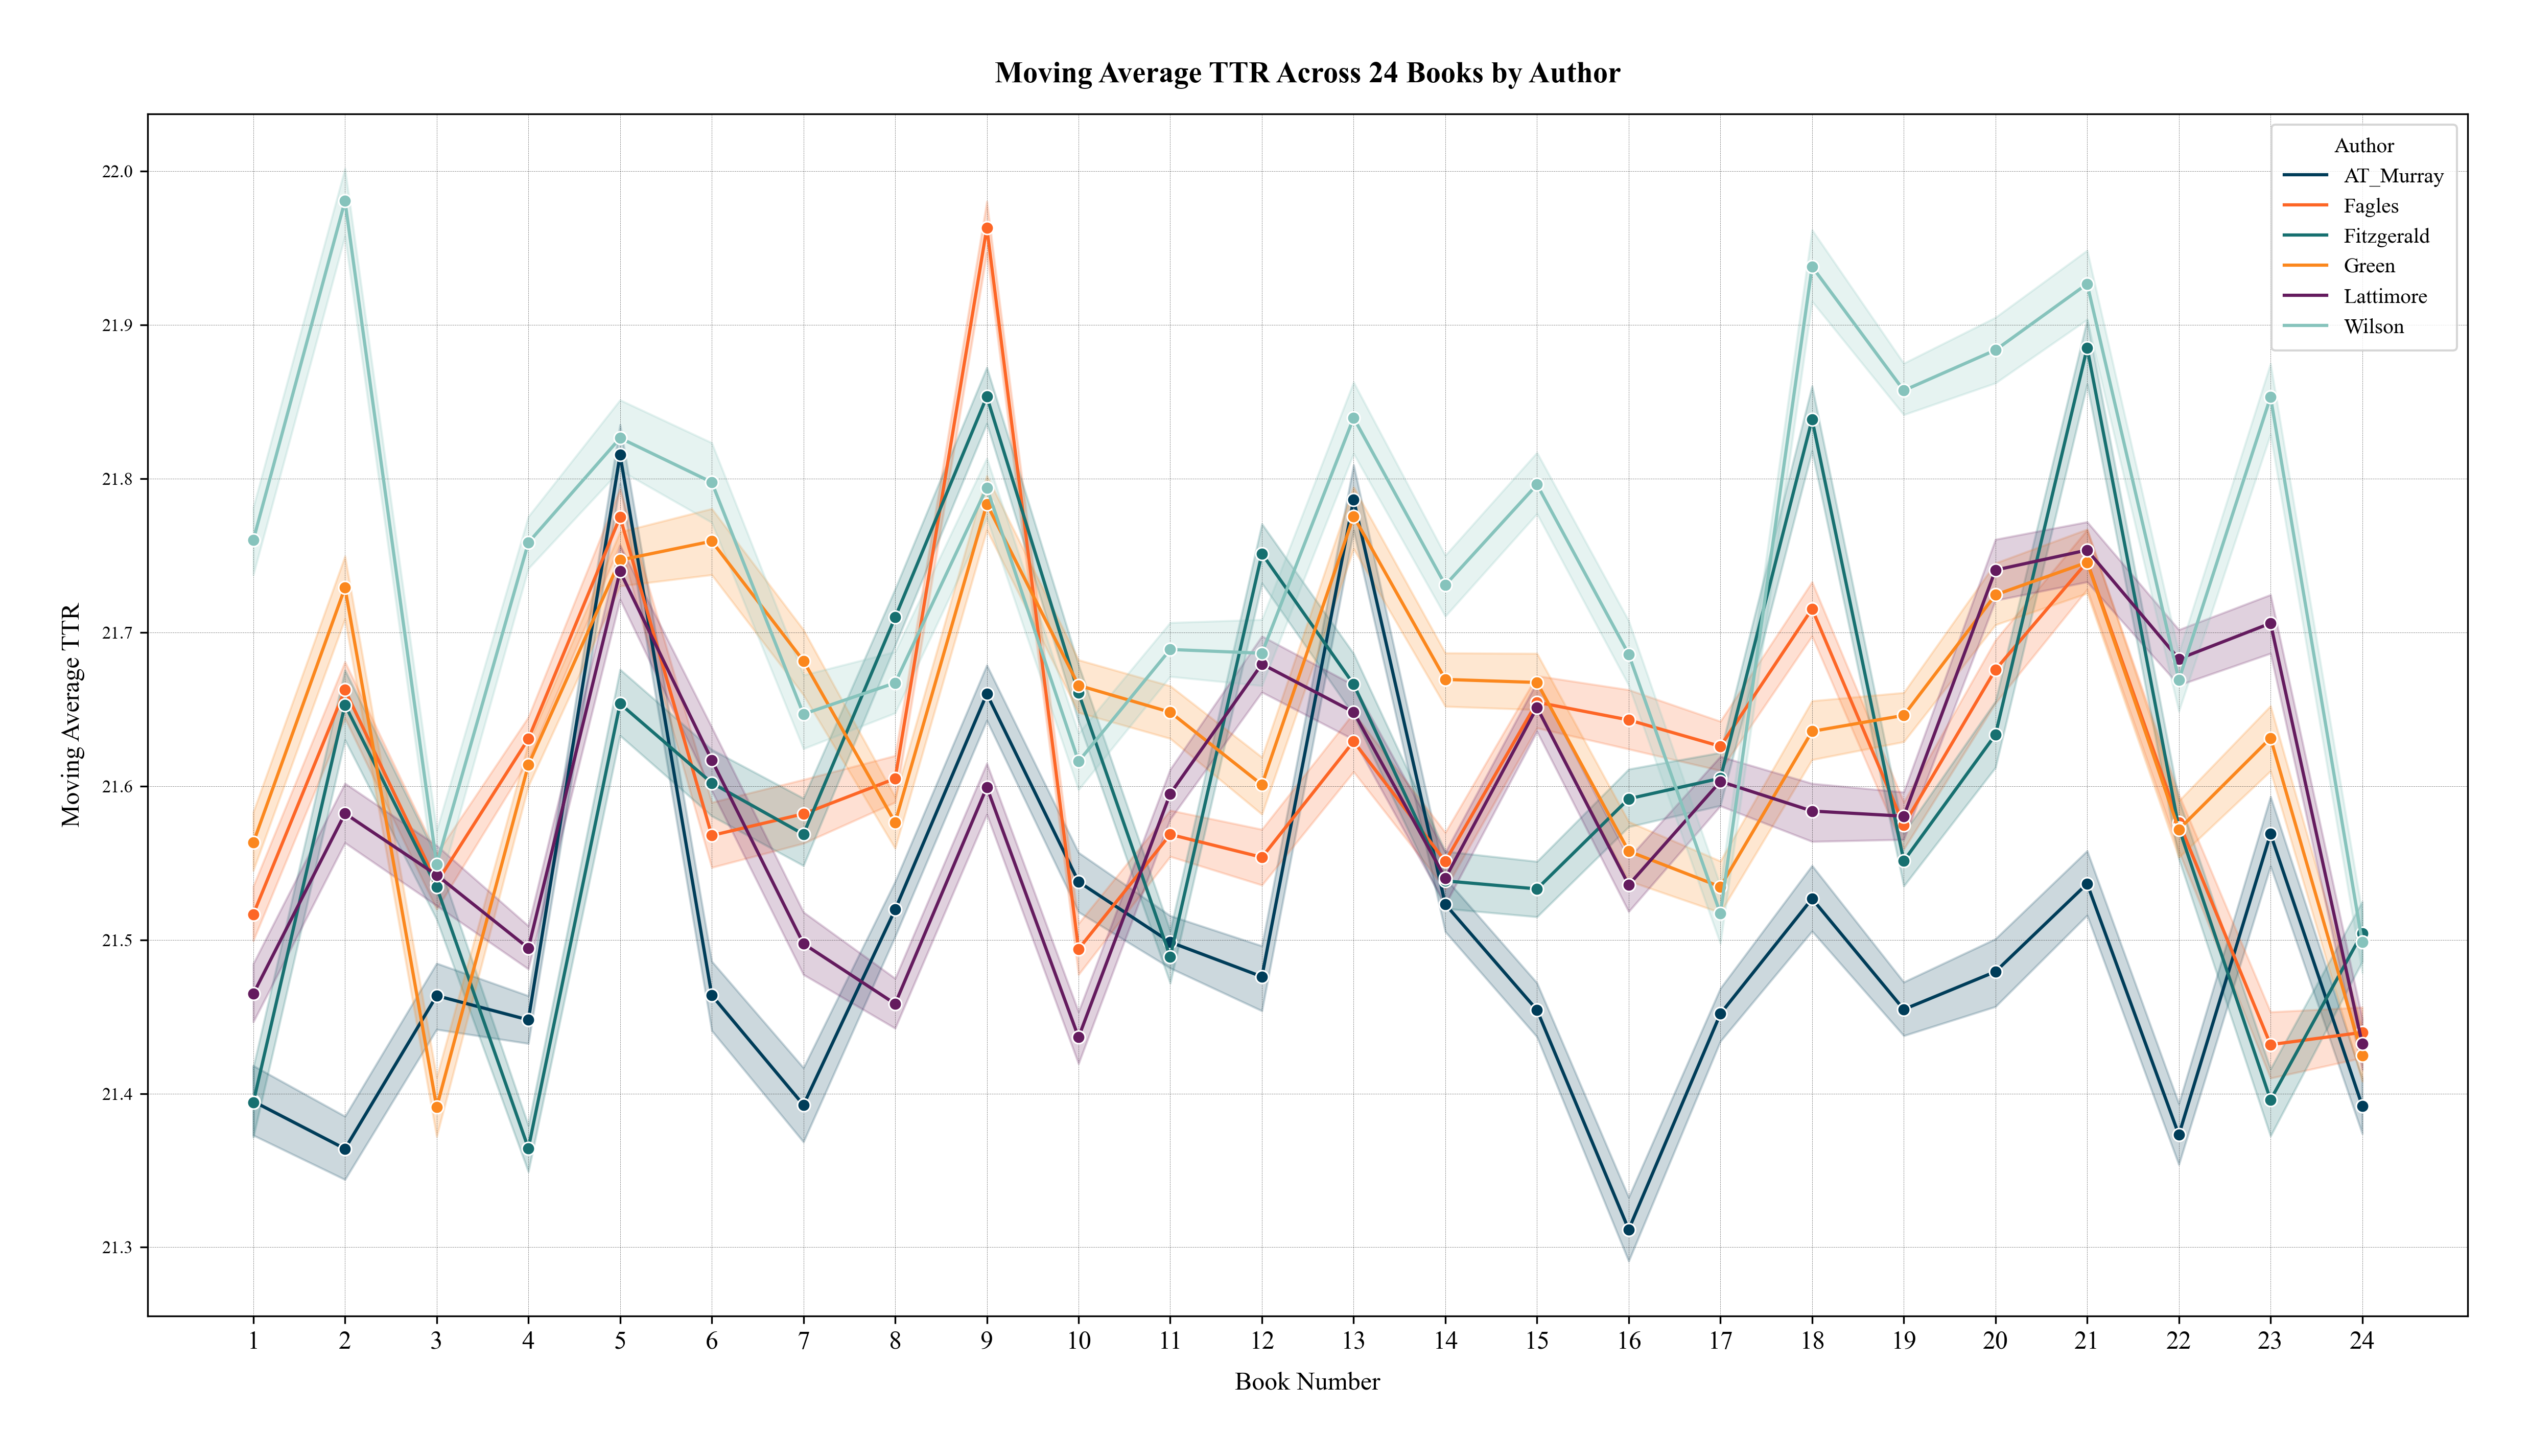

In [29]:
# ----------------------------------------------------------------------
# Plotting Moving-Average TTR
# ----------------------------------------------------------------------

# Explode the 'moving_average_ttr' column if it contains lists
if isinstance(df["moving_average_ttr"].iloc[0], list):  # Check if the column contains lists
    df = df.explode("moving_average_ttr")

# Convert to float (just in case)
df["moving_average_ttr"] = df["moving_average_ttr"].astype(float)

# Sort values by author and book number to ensure correct order
df = df.sort_values(by=["author", "book_num"])
plt.figure(figsize=(16, 9))

# Line plot: Moving Average TTR by author
sns.lineplot(data=df, x="book_num", y="moving_average_ttr", hue="author", marker="o")

plt.xlabel("Book Number", fontsize=12)
plt.ylabel("Moving Average TTR", fontsize=12)
plt.title("Moving Average TTR Across 24 Books by Author", fontsize=14)
plt.xticks(range(1, 25))  # Ensure x-axis labels from 1 to 24
plt.legend(title="Author")  
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout() 
plt.savefig(output_path_plots + f"moving_average_ttr-{nb_id}.png")
plt.show()